In [1]:
# =========================================
# 📚 IMPORT ALL REQUIRED LIBRARIES (TOP CELL)
# =========================================

# Data handling
import pandas as pd
import numpy as np

# Text processing
import re

# Machine Learning
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

# Models 
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression

# Evaluation
from sklearn.metrics import accuracy_score, classification_report
# Save model
import joblib
from sklearn.model_selection import cross_val_score
from sklearn.svm import LinearSVC
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV
import random
from sklearn.model_selection import learning_curve



In [2]:
#LOAD DATASET

In [3]:
# Load
data = pd.read_csv(
    "../datasets/tigrigna_translated_news_dataset(5).csv",
    encoding="utf-8-sig",   # 👈 IMPORTANT FIX
    sep=None,
    engine="python"
)

# Clean column names
data.columns = data.columns.str.strip()

# Inspect
print("Columns:", list(data.columns))

# Rename properly (adjust based on output)
data.columns = data.columns.str.replace('\ufeff', '', regex=True).str.strip()

data.rename(columns=lambda x: x.strip().lower(), inplace=True)

data.rename(columns={
    'tigrigna_translated_text': 'text',
    'label': 'label'
}, inplace=True)

print(data.columns)
print(data[['text']].head())

Columns: ['Tigrigna_translated_text', 'label']
Index(['text', 'label'], dtype='str')
                                                text
0  ላዕለዋይ ቤት ፍርዲ ማሳቹሰትስ ብዛዕባ ማእሰርቲ ስደተኛታት ዝሃቦ ውሳነ ...
1  ኣመሪካ ብሰንኪ እቲ ኣብ ልዕሊ ዘይመንግስታውያን ትካላት ዝተወሰነ ቀይዲ፡...
2  ረክስ ቲለርሰን ካብ ስልጣኖም ከምዘይለቁን ምስ ትራምፕ ጽቡቕ ርክብ ከምዘ...
3  ኣባላት ኮንግረስ ኣመሪካ ኣብ ልዕሊ ሩስያ ሓድሽ እገዳ ንምንባር ተሰማሚዖ...
4  ዶናልድ ትራምፕ ንገዛኢ ክፍለ-ሃገር ካንሳስ ሳም ብራውንባክ ኣምባሳደር ኣ...


In [4]:
import re

# ===============================
# 🧹 TEXT CLEANING FUNCTION (IMPROVED)
# ===============================

def clean_text(text):
    text = str(text)

    # ===========================
    # 1. Remove URLs
    # ===========================
    text = re.sub(r'https?://\S+|www\.\S+', '', text)

    # ===========================
    # 2. Remove email addresses
    # ===========================
    text = re.sub(r'\S+@\S+', '', text)

    # ===========================
    # 3. Remove Tigrigna punctuation
    # ===========================
    text = re.sub(r'[።፣፤፥፦፧፨]', '', text)

    # ===========================
    # 4. Remove English punctuation + symbols
    # ===========================
    text = re.sub(r'[.,;:!?()\[\]{}"\'`~@#$%^&*+=|\\/<>_-]', '', text)

    # ===========================
    # 5. Remove digits (Arabic + Western)
    # ===========================
    text = re.sub(r'[0-9\u1369-\u137C]', '', text)

    # ===========================
    # 6. Remove extra noise characters (safe Unicode filter)
    # ===========================
    text = re.sub(r'[^\w\s\u1200-\u137F]', '', text)

    # ===========================
    # 7. Normalize spaces
    # ===========================
    text = re.sub(r'\s+', ' ', text)

    return text.strip()


# Apply to dataset
data['clean_text'] = data['text'].apply(clean_text)

In [5]:
# ===============================
# 🧹 CLEAN LABELS (STRONG VERSION)
# ===============================

# Remove missing values early
data = data.dropna(subset=['text', 'label'])

# Convert label to numeric
data['label'] = pd.to_numeric(data['label'], errors='coerce')

# Drop invalid rows again
data = data.dropna(subset=['label'])

# Convert to int
data['label'] = data['label'].astype(int)

# Define X and y AFTER cleaning
X = data['text']
y = data['label']

print("Remaining NaN:", data['label'].isnull().sum())
print("Label values:", data['label'].unique())

Remaining NaN: 0
Label values: [1 0]


In [6]:
# ===============================
# 🔄 ADVANCED TIGRIGNA NORMALIZATION
# ===============================

def normalize_tigrigna(text):
    
    replacements = {
        # Alef variations
        "አ": "ኣ", "ዐ": "ኣ",

        # H group normalization
        "ሐ": "ሀ", "ኀ": "ሀ", "ሓ": "ሀ",

        # S group
        "ሰ": "ሠ", "ሸ": "ሠ",

        # Ts / T group
        "ጸ": "ፀ", "ፀ": "ፀ",

        # K variations
        "ከ": "ካ", "ኸ": "ካ",

        # Z variations
        "ዘ": "ዠ", "ዠ": "ዠ",

        # D variations
        "ደ": "ዳ", "ዸ": "ዳ",

        # G variations
        "ገ": "ጋ", "ጐ": "ጋ",

        # B variations
        "በ": "ባ", "ቨ": "ባ",

        # P variations
        "ፐ": "ፓ",

        # Vowel simplifications (optional but useful)
        "ኡ": "ኢ", "ኤ": "ኢ", "እ": "ኢ",
        "ኦ": "ኢ",

        # Remove elongations / repeated emphasis (optional)
        "፡": " ",
    }

    for k, v in replacements.items():
        text = text.replace(k, v)

    return text
    data['clean_text'] = data['clean_text'].apply(normalize_tigrigna)
    text = text.strip()

In [7]:
# Tokenization function
def tokenize(text):
    return re.findall(r'[A-Za-z]+|[ሀ-፿]+', text)

# Apply tokenization
data['tokens'] = data['clean_text'].apply(tokenize)

# Stopwords
stopwords = set([
"ኣነ","ንስኻ","ንስኺ","ንሱ","ንሳ","ንሕና","ንሳቶም","ንኣይ","ንእሱ","ንእሳ","ንእኛ","ንእኦም",
"እዚ","እቲ","እታ","እቶም","እዞም","እዚኣ","እቲኣ",
"እና","ወይ","ግን","ምኽንያቱ","ስለዚ","እኳ","እንተ","እንከ","እውን","ደጊም",
"ኣብ","ናብ","ካብ","ምስ","ብዘይ","ብዛዕባ","ን","ናይ","ብ","ላዕሊ","ታሕቲ",
"እዩ","እየ","እዮም","ነበረ","ነበሩ","ክኸውን","ኣለኒ","ኣለዎ","ኣለዋ","ኣሎ","ኣሎም",
"ግበር","ይገብር","ገበረ","ክኽእል","ክ","ምናልባት",
"ኣይ","የለን","ከቶ","ምንም","ዋላ","ኣይኮነን",
"ኩሉ","ብዙሕ","ሓደ","ገለ","ዝኾነ","ነፍሲ","ወከፍ","ዝያዳ","ንእሽቶ",
"ሕጂ","ከዚ","ቅድሚ","ድሕሪ","ኩሉ","ግዜ","ንኣንስ","ብዙሕ","ግዜ","ከቶ",
"ብቻ","ጥራይ","እውን","እኳ","ኣብዚ","ኣብቲ","ስለምንታይ","ከመይ","እንታይ","መን","ኣበይ",
"እዚኦም","እቶም","እዚኣቶም","እቲኦም","እዚኦን",
"ኣሎኹም","ኣለና","ኣሎኻ","ኣሎኺ","ኣሎኹ",
"ከም","ከምዚ","ከምኡ","ከምዚኦም","ከምኡን",
"ስለ","ስለዚ","ስለዚኣ","ስለዚኦም",
"ዝ","ዝኾነ","ዝኾነን","ዝኾነኦም",
"እንተኾነ","እንተዘይኮነ","እንተዘይ",
"ኣብዚኣ","ኣብዚኦም","ኣብቲኦም",
"ብዚ","ብኡ","ብዚኦም",
"ካብዚ","ካብኡ","ካብኦም",
"ናብዚ","ናብኡ","ናብኦም",
"ምስዚ","ምስኡ","ምስኦም",
"ብዙሕ","ግዜ","ኣንስ","ኩሉ","ግዜ","ሓደ","ግዜ",
"ድሕሪኡ","ቅድሚኡ","ሕጂኡ",
"እዚኣ","እዚኦም","እቲኦም","እታኦም",
"ኣይኮነን","ኣይኮነንን","ኣይኮነንንን",
"ኣሎን","የለንን","ኣሎንን",
"ሓደ","ሓደን","ሓደንን",
"ከምዚ","ከምኡ","ከምኡን","ከምዚን",
"እንተ","እንተኾነ","እንተዘይ","እንተዘይኮነ",
"እዚ","እቲ","እታ","እቶም","እዞም",
"ዝ","ዝኾነ","ዝኾነን",
"እና","እናደር","እናበለ","እናሃበ",
"እውን","ደጊም","እኳ","እኳን",
"ን","ናይ","ብ","ኣብ","ካብ","ናብ",
"እንታይ","መን","ከመይ","ኣበይ",
"እዚኣ","እቲኣ","እታኣ","እቶምኣ",
"ክ","ክኸውን","ክግበር","ክኽእል",
"ምናልባት","ከምዚ","ከምኡ",
"እዩ","እየ","እዮም","እዩን","እየን",
"ነበረ","ነበሩ","ነበርኩም","ነበርና",
"ኣሎ","ኣለ","ኣሎም","ኣሎን","ኣሎኻ","ኣሎኺ",
"የለን","የለንን","የለንንን",
"ከቶ","ምንም","ዋላ","ዋላኳ",
"ኩሉ","ገለ","ሓደ","ብዙሕ","ንእሽቶ",
"ኩሉ","ግዜ","ብዙሕ","ግዜ","ንኣንስ","ግዜ",
"ሕጂ","ከዚ","ቅድሚ","ድሕሪ","እንከ",
"ኣብዚ","ኣብቲ","ኣብዚኣ","እምበር","ይኹን","ኣብቲኣ","ከምዘሎ"
])

# Clean tokens function
def clean_tokens(tokens):
    return [word for word in tokens if word not in stopwords]

# Apply stopword removal
data['tokens'] = data['tokens'].apply(clean_tokens)

# Join tokens into text
data['processed_text'] = data['tokens'].apply(lambda x: " ".join(x))

In [8]:
print(data['tokens'].iloc[7])

['ምምሕዳር', 'ትራምፕ', 'ስምምዕ', 'ናፍታ', 'NAFTA', 'ምትእስሳር', 'ባጤራ', 'ንምቁጽጻር', 'መምርሒ', 'ክውስኽ', 'ይሓስብ', 'ዋሽንግተን', 'ሮይተርስ', 'ሚኒስተር', 'ፋይናንስ', 'ኣመሪካ', 'ስቲቨን', 'ምኑቺን', 'ሓሙስ', 'ዝገለጽዎ፡', 'ምምሕዳር', 'ትራምፕ', 'ኣካል', 'ናይቲ', 'ንመጻኢ', 'ዝግበሩ', 'ነጻ', 'ንግዲ', 'ስምምዓት', 'መደቡ፡', 'ሰሜን', 'ኣመሪካ', 'ነጻ', 'ንግዲ', 'ስምምዕ', 'NAFTA', 'ምትእስሳር', 'ባጤራ', 'currency', 'manipulation', 'ንምክልኻል', 'ዘኽእል', 'መምርሒ', 'ንምእታው', 'ይጽዕር', 'ሓቢሮም', 'ምኑቺን', 'ኮሚቴ', 'ፋይናንሳዊ', 'ኣገልግሎት', 'ቤት', 'ምኽሪ', 'ወከልቲ', 'ህዝቢ', 'ዝሃብዎ', 'ቃል፡', 'ብወገን', 'መሻርኽቲ', 'ንግዲ', 'ኣመሪካ', 'ዝግበር', 'ባጤራ', 'ምትእስሳር', 'ብተግባር', 'ዝርአ', 'ሳዕቤን', 'ክህልዎ', 'ዝግባእ', 'ብዘረባ', 'ከምዘይብሉ', 'ገሊጾም', 'ንሶም', 'ወሲኾም', 'ዝበልዎ፡', 'ትካል', 'ኣህጉራዊ', 'ቁጠባ', 'ፒተርሰን', 'Peterson', 'Institute', 'for', 'International', 'Economics', 'ዝቐረበ', 'ሓሳብ፡', 'ማለት', 'ሚኒስትሪ', 'ፋይናንስ', 'ነቲ', 'ብፍላጥ', 'ክወርድ', 'ዝግበር', 'ዘሎ', 'ሓንቲ', 'ሃገር', 'ባጤራ', 'ብምዕዳግ', 'ጣልቃ', 'ንክኣቱ', 'countervailing', 'currency', 'interventions', 'ዝግበር', 'ጻዕሪ፡', 'ካብቶም', 'ብዙሓት', 'ኣማራጺታት', 'ይኽእል', 'እምበር፡', 'ምኑቺን', 'ዝበለ', 'ስርሒታት', 'ንምክያድ', 'ዘድሊ', 'መጠን', 'ገንዘብ', 'ኣዝዩ', 'ዓ

In [9]:
print("እውን" in data['tokens'].iloc[8])
print("ይኹን" in data['tokens'].iloc[8])

False
False


In [10]:

X = data['processed_text']
y = data['label']
print(data['processed_text'].iloc[14])

ፑቲን፡ ዋሽንግተን ሓድሽ እገዳታት እንተቀጺላ ሩስያ ግብረመልሲ ክትህብ ምዃና ኣጠንቂቖም ሳቮንሊና፡ ፊንላንድ ሮይተርስ ፕረዚደንት ቭላድሚር ፑቲን ሓሙስ ዝገለጽዎ፡ ዋሽንግተን ነቲ ዘይሕጋዊ ሓድሽ እገዳታት ዝበልዎ ልዕሊ ሞስኮ እንተደፍኣሉ፡ ሩስያ ግብረመልሲ ክትህብ ክትግደድ ምዃና ገሊጾም ንተግባር ኣመሪካ ልዕሊ ሃገሮም ድማ ብልሓት ዘይብሉን ዘይርትዓውን boorish and unreasonable ክብሉ ገሊጾምዎ ፑቲን ፊንላንድ ዝገበርዎ ምብጻሕ፡ ሰሉስ ብቤት ምኽሪ ወከልቲ ህዝቢ ኣመሪካ House of Representatives ዝሓለፈ፡ ልዕሊ ሩስያ ሓድሽ እገዳታት ንምንባርን ፕረዚደንት ዶናልድ ትራምፕ እገዳታት ምፍካሶም ኣባላት ኮንግረስ ፍቓድ ክሓትቱ ዘገድድን ውሳነ ርእይቶ ሂቦም ኣለዉ እገዳታት ገና ብሰነድ ብትራምፕ ኣይጸደቐን ላዕለዋይ በዓል ስልጣን ዋይት ሃውስ ድማ ሓሙስ ዝበሎ፡ ትራምፕ ሓያል ስምምዕ ንምርካብ ነቲ ሕጊ መሰል ቪቶ veto ተጠቒሞም ክዓግትዎ ይኽእሉ ፑቲን፡ ሩስያ ዝሓለፈ ዓመት ምርጫ ፕረዚደንት ኣመሪካ ኢዳ ኣእትያ እያ ንዝብል ክሲ ደጋጊሞም ዝነጸጉ ኮይኖም፡ ሞስኮ ብኸመይ ግብረመልሲ እትህብ ክትውስን እትኽእል ዝቐረበ ረቂቕ ሕጊ መወዳእታ ትሕዝቶኡ ረኣየት ምዃኑ ገሊጾም እትፈልጥዎ፡ ዓቕልን ትዕግስትን ንገብር እዋን ግብረመልሲ ክንህብ ክንገደድ ኢና ነዚ ልዕሊ ሃገርና ዝግበር ዘሎ ድንቁርና ንዘልኣለም ክንዕገሶ ኣይከኣልን ክብሉ ፑቲን ምስቲ ፊንላንዳዊ መዘንኦም ዝሃብዎ ሓባራዊ ጋዜጣዊ መግለጺ ተዛሪቦም መልስና መዓስ እንታይከ ሰነድ ኣመሪካ ዝዝተየሉ ዘሎ መወዳእታ ትሕዝቶ ረቂቕ ሕጊ ክምርኮስ ፑቲን ብተወሳኺ ዝሓለፈ ታሕሳስ ጀሚሩ መንጎ ሞስኮን ዋሽንግተንን ዘሎ ዲፕሎማስያዊ ምስሕሓብ ተዛሪቦም ሽዑ ፕረዚደንት ባራክ ኦባማ ንንብረት ዲፕሎማስያዊ ቤት ጽሕፈት

In [11]:
# ===============================
# ✂️ TRAIN-TEST SPLIT
# ===============================

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 80% train, 20% test
    random_state=42,stratify=y
)


In [12]:
assert y_train.isnull().sum() == 0, "Still contains NaN!"

In [13]:
print("y_train NaN:", y_train.isnull().sum())

y_train NaN: 0


In [14]:
print(X_train.shape)
print(X_test.shape)

(2401,)
(601,)


In [15]:
# ===============================
#TF-IDF (Term Frequency – Inverse Document Frequency)
# 🎯 DEFINE FEATURES AND LABEL
# ===============================



In [16]:

vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2)
)
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)
print(len(X_train), len(y_train))
print(len(X_test), len(y_test))
print(X_train_vec.shape[0], len(y_train))
print(X_train_vec.shape)
print(X_test_vec.shape)

2401 2401
601 601
2401 2401
(2401, 5000)
(601, 5000)


In [17]:
#MODEL TRAINING (Fake News Classifier) 

In [18]:
nb_model = MultinomialNB()
nb_model.fit(X_train_vec, y_train)

nb_pred = nb_model.predict(X_test_vec)

print("Naive Bayes Accuracy:", accuracy_score(y_test, nb_pred))
print(classification_report(y_test, nb_pred))

Naive Bayes Accuracy: 0.9267886855241264
              precision    recall  f1-score   support

           0       0.92      0.94      0.93       301
           1       0.94      0.92      0.93       300

    accuracy                           0.93       601
   macro avg       0.93      0.93      0.93       601
weighted avg       0.93      0.93      0.93       601



In [19]:
# ===============================
# 🤖 LOGISTIC REGRESSION
# ===============================

lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train_vec, y_train)

lr_pred = lr_model.predict(X_test_vec)

print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_pred))
print(classification_report(y_test, lr_pred))

Logistic Regression Accuracy: 0.9450915141430949
              precision    recall  f1-score   support

           0       0.94      0.96      0.95       301
           1       0.96      0.93      0.94       300

    accuracy                           0.95       601
   macro avg       0.95      0.95      0.95       601
weighted avg       0.95      0.95      0.95       601



In [20]:
param_grid = {
    'C': [0.1, 1, 5, 10]
}

grid = GridSearchCV(
   LinearSVC(class_weight='balanced'),
    param_grid,
    cv=3,
    scoring='accuracy'
)

grid.fit(X_train_vec, y_train)

print("Best Parameters:", grid.best_params_)
print("Best Score:", grid.best_score_)

Best Parameters: {'C': 1}
Best Score: 0.9616833125260092


In [21]:
# ===============================
# 🤖 SVM MODEL (STRONG MODEL)
# ===============================
best_svm = grid.best_estimator_

svm_pred = best_svm.predict(X_test_vec)
print("SVM Accuracy:", accuracy_score(y_test, svm_pred))

print(classification_report(y_test, svm_pred))

SVM Accuracy: 0.9600665557404326
              precision    recall  f1-score   support

           0       0.95      0.97      0.96       301
           1       0.97      0.95      0.96       300

    accuracy                           0.96       601
   macro avg       0.96      0.96      0.96       601
weighted avg       0.96      0.96      0.96       601



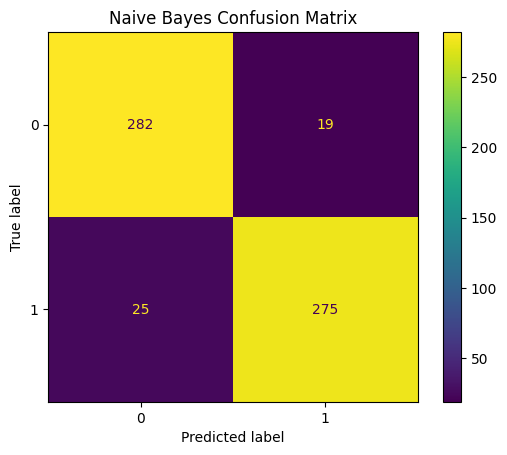

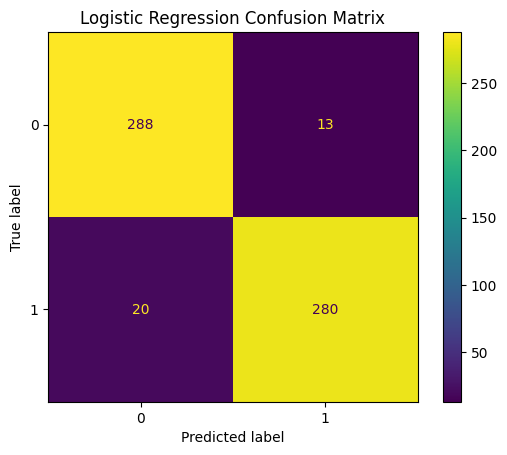

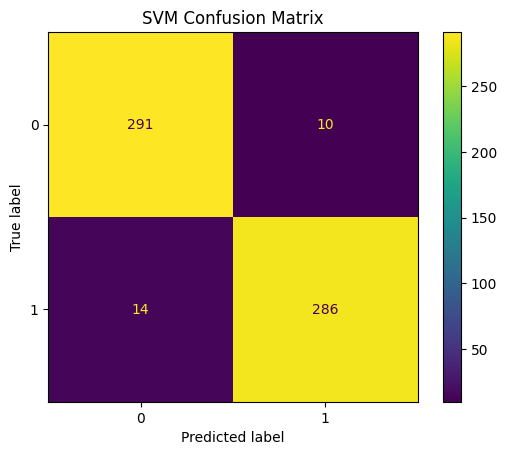

In [22]:
# ===============================
# 📊 ALL CONFUSION MATRICES
# ===============================

models = {
    "Naive Bayes": nb_pred,
    "Logistic Regression": lr_pred,
    "SVM": svm_pred
}

for name, pred in models.items():
    cm = confusion_matrix(y_test, pred)
    
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    
    plt.title(f"{name} Confusion Matrix")
    plt.show()

In [23]:
print("\nNaive Bayes Report:", accuracy_score(y_test, nb_pred))
print(classification_report(y_test, nb_pred))
print("\nLogistic Regression Report:",accuracy_score(y_test,lr_pred))
print(classification_report(y_test, lr_pred))
print("SVM Accuracy:", accuracy_score(y_test, svm_pred))
print(classification_report(y_test, svm_pred))


Naive Bayes Report: 0.9267886855241264
              precision    recall  f1-score   support

           0       0.92      0.94      0.93       301
           1       0.94      0.92      0.93       300

    accuracy                           0.93       601
   macro avg       0.93      0.93      0.93       601
weighted avg       0.93      0.93      0.93       601


Logistic Regression Report: 0.9450915141430949
              precision    recall  f1-score   support

           0       0.94      0.96      0.95       301
           1       0.96      0.93      0.94       300

    accuracy                           0.95       601
   macro avg       0.95      0.95      0.95       601
weighted avg       0.95      0.95      0.95       601

SVM Accuracy: 0.9600665557404326
              precision    recall  f1-score   support

           0       0.95      0.97      0.96       301
           1       0.97      0.95      0.96       300

    accuracy                           0.96       601
   macr

In [ ]:


train_sizes = np.linspace(0.1, 1.0, 10)

train_sizes_abs, train_scores, test_scores = learning_curve(
    best_svm,
    X_train_vec,
    y_train,
    train_sizes=train_sizes,
    cv=5,
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)

plt.figure(figsize=(8,5))

plt.plot(train_sizes_abs, train_mean, label="Training Score")
plt.plot(train_sizes_abs, test_mean, label="Validation Score")

plt.title("Learning Curve")
plt.xlabel("Training Size")
plt.ylabel("Score")
plt.legend()

plt.grid()
plt.show()

In [ ]:
# ===============================
# 📊 MODEL COMPARISON TABLE
# ===============================

model_names = ["Naive Bayes", "Logistic Regression", "SVM"]

accuracies = [
    accuracy_score(y_test, nb_pred),
    accuracy_score(y_test, lr_pred),
    accuracy_score(y_test, svm_pred)
]

comparison_df = pd.DataFrame({
    "Model": model_names,
    "Accuracy": accuracies
})

print(comparison_df)

In [ ]:
# ===============================
# 📈 PROFESSIONAL MODEL COMPARISON GRAPH
# ===============================

plt.figure(figsize=(8, 5))

bars = plt.bar(model_names, accuracies)

plt.title("Model Accuracy Comparison", fontsize=14)
plt.xlabel("Models", fontsize=12)
plt.ylabel("Accuracy", fontsize=12)

# Add value labels on top of bars
for i, v in enumerate(accuracies):
    plt.text(i, v + 0.002, f"{v:.2f}", ha='center', fontsize=10)

plt.ylim(0.9, 1.0)  # zoom into accuracy range for clarity

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

In [ ]:
# ===============================
# 📊 PRECISION / RECALL / F1 GRAPH
# ===============================

from sklearn.metrics import precision_score, recall_score, f1_score

precision = [
    precision_score(y_test, nb_pred),
    precision_score(y_test, lr_pred),
    precision_score(y_test, svm_pred)
]

recall = [
    recall_score(y_test, nb_pred),
    recall_score(y_test, lr_pred),
    recall_score(y_test, svm_pred)
]

f1 = [
    f1_score(y_test, nb_pred),
    f1_score(y_test, lr_pred),
    f1_score(y_test, svm_pred)
]

x = np.arange(len(model_names))

plt.figure(figsize=(8,5))
plt.ylim(0.85, 1.0)

plt.bar(x - 0.2, precision, width=0.2, label="Precision")
plt.bar(x, recall, width=0.2, label="Recall")
plt.bar(x + 0.2, f1, width=0.2, label="F1 Score")

plt.xticks(x, model_names)
plt.title("Model Performance Comparison")
plt.legend(loc='upper left', bbox_to_anchor=(1,1))

plt.show()

In [ ]:
best_model = comparison_df.loc[comparison_df['Accuracy'].idxmax()]
print("Best Model:", best_model["Model"])
print("Best Accuracy:", best_model["Accuracy"])

In [ ]:
scores = cross_val_score(best_svm, X_train_vec, y_train, cv=5)

print("SVM Cross Validation Accuracy:", scores.mean())

In [ ]:
# ===============================
# 🔍 RANDOM TEST FROM DATASET
# ===============================


def predict_news(text):
    processed = text
    
    # If you still want preprocessing:
    tokens = tokenize(text)
    tokens = clean_tokens(tokens)
    processed = " ".join(tokens)

    vec = vectorizer.transform([processed])

    pred = best_svm.predict(vec)

    return "REAL" if pred[0] == 1 else "FAKE"

In [ ]:
def predict_with_confidence(text):
    tokens = tokenize(text)
    tokens = clean_tokens(tokens)
    processed = " ".join(tokens)

    vec = vectorizer.transform([processed])

    decision = best_svm.decision_function(vec)[0]
    prediction = best_svm.predict(vec)[0]

    return prediction, decision

In [ ]:
for i in range(5):
    idx = random.randint(0, len(data)-1)

    text = data['processed_text'].iloc[idx]
    actual = data['label'].iloc[idx]

    prediction = predict_news(text)

    print("\n📝 TEXT:", text[:1000], "...")
    print("✅ ACTUAL:", "REAL" if actual == 1 else "FAKE")
    print("🤖 PREDICTED:", prediction)

In [ ]:
# ===============================
# ❌ SHOW WRONG PREDICTIONS
# ===============================

wrong = []

for i in range(len(X_test)):
    pred = best_svm.predict(X_test_vec[i])
    actual = y_test.iloc[i]

    if pred != actual:
        wrong.append(i)

print("Total wrong predictions:", len(wrong))

In [ ]:
for i in wrong[:5]:
    print("\n📝 TEXT:", X_test.iloc[i][:1000])
    print("❌ ACTUAL:", y_test.iloc[i])
    print("🤖 PREDICTED:", best_svm.predict(X_test_vec[i])[0])

In [ ]:
scores = cross_val_score(best_svm, X_train_vec, y_train, cv=5)

print("Cross-validation scores:", scores)
print("Average:", scores.mean())

In [ ]:
print("Before saving:")
print("Has IDF:", hasattr(vectorizer, "idf_"))

In [ ]:
# ===============================
# 💾 SAVE MODEL
# ===============================
joblib.dump(best_svm, "../models/svm_model.pkl")
joblib.dump(vectorizer, "../models/vectorizer.pkl")
joblib.dump(stopwords, "../models/stopwords.pkl")

In [ ]:
import joblib

v = joblib.load("../models/vectorizer.pkl")

print("Has IDF:", hasattr(v, "idf_"))
print("Vocab size:", len(v.vocabulary_))